# Crash!💥 Boom!💥 Bang! 💥🚗🚙💥🚗
**A SQL based exploratory data analysis of traffic accidents in Okinawa, Japan**
  
---   
# <span style="color:#0279f0;">Part 3: Spatial Analysis</span>
---
Now that we have a big picture overview of the accidents in 2024, let's take a closer look at WHERE the accidents occurred.  

**Analysis Tasks**    
1. **Accidents by Municipality** - Municipalities and their accident counts
2. **High Risk Roads and Junctions** - Which particular roads or junctions have higher accident counts?
3. **Black Spot Analysis** - Which areas show the highest concentration of accidents?

**Formula**  
`Accident Share (%) = Municipality Accident Count / Total Accidents × 100`

**Tools used in this notebook:**
- Pandas – for loading the CSV, quick checks and basic data manipulation.
- DuckDB – for all aggregation queries
- Matplotlib / Seaborn – for visualisations

##### 👩🏻‍💻  *<span style="color:#0279f0">Loading data to begin...</span>*

In [1]:
import sys
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from sql.notebook_setup import *

# Load data with pandas
accidents_df = load_data(FILTERED_DATA_PATH)
municipal_df = load_data(MUNICIPAL_DATA_PATH)

# Connect to DuckDB
conn = create_connection()
# Register dataframes with DuckDB
register_table(conn, "accidents", accidents_df)
register_table(conn, "municipality", municipal_df)

#Verify dataset is loaded
print_summary(accidents_df,"`Accidents` Table",10)
print_summary(municipal_df,"`Municipality` Codes Table")



✅ `Accidents` Table: 2,749 records
----------------------------------------
✅ Showing 10 of 68 columns:
 1. data_category
 2. prefecture_code
 3. police_station_code
 4. report_id
 5. accident_details_code
 6. fatalities
 7. injured_persons
 8. route_code
 9. location_code
10. municipality_code
... 58 additional columns

✅ `Municipality` Codes Table: 41 records
----------------------------------------
✅ Showing 3 of 3 columns:
 1. municipality_code
 2. municipality_name
 3. region


..........  

### **3.1 Accident Counts by Municipality & Region**  
How do different municipals and regions fare in terms of accident count?

##### 👩🏻‍💻  *<span style="color:#0279f0">SQL: Analyzing Municipality Accident Counts...</span>*

In [2]:
# ==========================
# 3.1 Accident Counts by Municipality & Region
# Step 1. Create the temporary view
# Step 2. Total accidents per municipality
# Step 3. Aggregate top 4 municipalities with the most accidents
# Step 4. Aggregate by region
# ==========================

# Step 1: Create the temporary view
conn.execute("""
CREATE OR REPLACE TEMP VIEW municipality_counts AS
SELECT
    m.municipality_name,
    COUNT(*) AS accident_count
             
FROM accidents a
LEFT JOIN municipality m
    ON a.municipality_code = m.municipality_code
GROUP BY m.municipality_name;

""")


# Step 2: Aggregate Accident Count by all municipalities
query_municipality ="""
SELECT
  municipality_name,
  accident_count,
  ROUND(accident_count *100 / SUM(accident_count) OVER(), 2) as percentage
FROM municipality_counts
ORDER BY accident_count DESC;
"""


# Print the results
results_municipality = conn.execute(query_municipality).fetchdf()
print("\n----------------------------------------")
print("All Municipalities")
print("----------------------------------------")
display(results_municipality)



----------------------------------------
All Municipalities
----------------------------------------


,municipality_name,accident_count,percentage
0,Naha City,543,19.75
1,Okinawa City,276,10.04
2,Urasoe City,249,9.06
3,Itoman City,233,8.48
4,Uruma City,152,5.53
5,Nago City,140,5.09
6,Haebaru Town,131,4.77
7,Ishigaki City,117,4.26
8,Chatan Town,111,4.04
9,Tomigusuku City,101,3.67


In [3]:
# Step 3: Aggregate Accident Count of Top 4 Municipalities with the most accidents
query_top4 ="""
SELECT
  SUM(accident_count) AS Top_4,
  ROUND(
    SUM(accident_count) *100 / 
    (SELECT SUM(accident_count) FROM municipality_counts),
    2
  ) AS percentage

FROM (
  SELECT accident_count
  FROM municipality_counts
  ORDER BY accident_count DESC
  Limit 4
) top4;
"""


results_top4 = conn.execute(query_top4).fetchdf()
print("\n----------------------------------------")
print("Top 4 Municipalities")
print("----------------------------------------")
display(results_top4)



----------------------------------------
Top 4 Municipalities
----------------------------------------


,Top_4,percentage
0,1301.0,47.33


In [4]:
# Step 4: Aggregate by region

# Pre-check: List of regions and municipalities under each region
# list_region=conn.execute("""SELECT region, municipality_name FROM municipality ORDER BY region, municipality_name;""".fetch_df()
#list_region


# Step 4: Aggregate accident counts by region
query_region ="""
SELECT
  m.region,
  COUNT(*) AS accident_count,
  ROUND(COUNT(*) * 100 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM accidents a
LEFT JOIN municipality m
  ON a.municipality_code = m.municipality_code
GROUP BY m.region
ORDER BY accident_count DESC;

"""


results_region = conn.execute(query_region).fetchdf()
print("\n----------------------------------------")
print("Accident Counts By Region")
print("----------------------------------------")
display(results_region)



----------------------------------------
Accident Counts By Region
----------------------------------------


,region,accident_count,percentage
0,South,1164,42.34
1,Central,1131,41.14
2,North,235,8.55
3,Yaeyama,121,4.40
4,Miyako,98,3.56


### 📊 <span style="color:orange;">3.1 Key Findings: Accidents by Municipality and Region</span>

| Category | Municipality / Region | Accidents | Share | Key Insight |
|---|---|---:|---:|---|
| Top Municipality | Naha City | 543 | 19.75% | Naha City recorded the highest number of accidents, accounting for nearly one in five accidents in Okinawa Prefecture. |
| 2nd Highest | Okinawa City | 276 | 10.04% | Recorded approximately half the number of accidents observed in Naha City. |
| Top 4 Municipalities | Naha City, Okinawa City, Urasoe City, Itoman City | 1,301 | 47.33% | Together, the four municipalities accounted for nearly half of all recorded accidents in the prefecture. |
| South Region | South | 1,164 | 42.34% | Recorded the highest share of accidents, reflecting the concentration of major urban municipalities such as Naha City, Itoman City, and Tomigusuku City. |
| Central Region | Central | 1,131 | 41.14% | Contributed a similarly high share of accidents, driven by municipalities including Okinawa City, Urasoe City, Uruma City, and Ginowan City. |
| South + Central Combined | South & Central | 2,295 | 83.48% | More than four out of every five recorded accidents occurred in the South and Central regions, highlighting the concentration of accidents in Okinawa's primary urban and suburban areas. |
| North Region | North | 235 | 8.55% | Recorded substantially fewer accidents than the South and Central regions, consistent with lower population density and traffic volumes. |
| Yaeyama Region | Yaeyama | 121 | 4.40% | Represented a relatively small share of prefecture-wide accidents, with most occurring in Ishigaki City. |
| Miyako Region | Miyako | 98 | 3.56% | Accounted for the smallest regional share among the inhabited island groups analyzed. |

..........  

### **3.2 High Risk Roads & Junctions**  
Now that we have identified the high risk municipalities, it's time to zoom in and find out which roads and junctions within these areas are the most dangerous.  Which routes contain the greatest number of high-frequency accident locations?

##### 👩🏻‍💻  *<span style="color:#0279f0">Analyzing Roads...</span>*

In [5]:
query_routes = """
SELECT
  route_code,
  COUNT(*) as accident_count,
  SUM(fatalities) as fatalities,
  SUM(injured_persons) as injuries,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
FROM accidents
GROUP BY route_code
ORDER BY accident_count DESC
LIMIT 10
"""

result_routes = conn.execute(query_routes).fetchdf()


query_routes_kp = """
SELECT
    route_code,
    location_code AS km_post_raw,
    ROUND(location_code / 10.0, 2) AS km_post,
    COUNT(*) AS accident_count,
    SUM(fatalities) AS fatalities,
    SUM(injured_persons) AS injured
FROM accidents
WHERE location_code <> 0
GROUP BY ALL
ORDER BY accident_count DESC
LIMIT 30
"""

results_routes_kp = conn.execute(query_routes_kp).fetchdf()


print("\n\n----------------------------------------")
print("💥Top 30 Route & KM-Post By Accidents:")
print("----------------------------------------")
display(results_routes_kp)





----------------------------------------
💥Top 30 Route & KM-Post By Accidents:
----------------------------------------


,route_code,km_post_raw,km_post,accident_count,fatalities,injured
0,27560,115,11.5,7,0.0,9.0
1,3300,57,5.7,5,0.0,7.0
2,580,1121,112.1,5,0.0,6.0
3,580,1192,119.2,5,0.0,5.0
4,580,672,67.2,5,0.0,5.0
5,580,1100,110.0,5,0.0,5.0
6,580,1069,106.9,5,0.0,6.0
7,3290,671,67.1,5,0.0,5.0
8,580,1087,108.7,5,0.0,5.0
9,580,1034,103.4,4,0.0,4.0


### 📊 <span style="color:orange;">3.2.1 Key Findings: Accidents by Route</span>

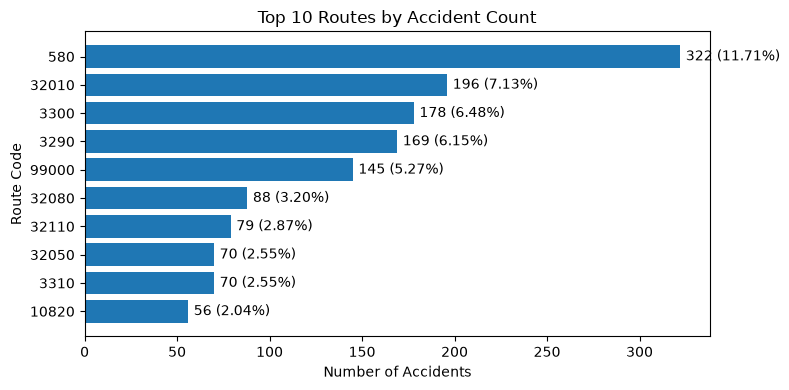

In [6]:
plot_data = result_routes.sort_values(
    "accident_count",
    ascending=True
)

plt.figure(figsize=(8, 4))
bars = plt.barh(
    plot_data["route_code"].astype(str),
    plot_data["accident_count"]
)

plt.xlabel("Number of Accidents")
plt.ylabel("Route Code")
plt.title("Top 10 Routes by Accident Count")

for bar, percentage in zip(bars, plot_data["percentage"]):
    plt.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())} ({percentage:.2f}%)",

        va="center"
    )

plt.tight_layout()
plt.show()



#### Top 10 Routes by Accident Count

#### Key Insights

- **National Highway Route 58 (Route Code 580)** recorded **322 accidents (11.71%)**. It is the highest-risk route in the dataset with an accident count that's substantially higher than any other route.

- **Naha municipal roads** (route codes beginning with **32**) appear **five times** in the top 10. This highlights the concentration of accidents within Okinawa's capital and its surrounding urban road network.

- **Routes 329 and 330** ranked **3rd** and **4th**, indicating that Okinawa's eastern arterial corridor also experiences a high volume of traffic accidents.

- Together, the top-ranked routes indicate that accidents are concentrated on Okinawa's primary urban and arterial road network rather than being evenly distributed across the prefecture.


### 📍 <span style="color:orange;">3.2.2 Key Findings: Route & KM-Post Analysis</span>


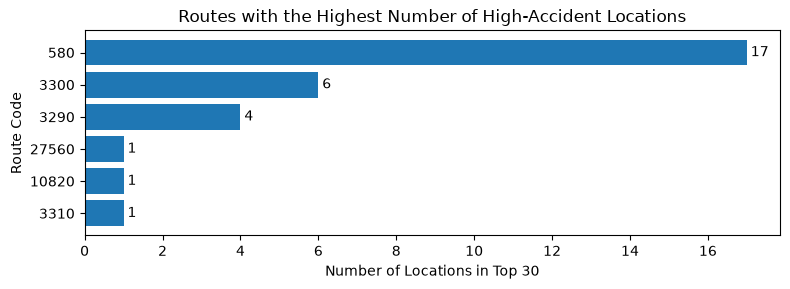

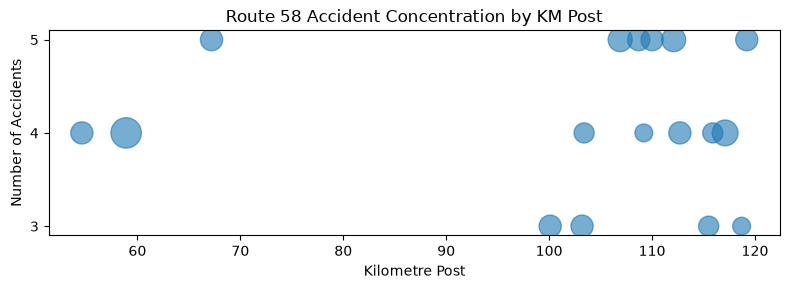

Note: Point size represents the number of injured persons recorded at each KM-post location.


In [7]:
route_hotspots = (
    results_routes_kp
    .groupby("route_code")
    .size()
    .reset_index(name="number_of_top_locations")
    .sort_values("number_of_top_locations", ascending=True)
)

plt.figure(figsize=(8, 3))

bars = plt.barh(
    route_hotspots["route_code"].astype(str),
    route_hotspots["number_of_top_locations"]
)

plt.xlabel("Number of Locations in Top 30")
plt.ylabel("Route Code")
plt.title("Routes with the Highest Number of High-Accident Locations")

for bar in bars:
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center"
    )

plt.tight_layout()
plt.show()

#Scatter plot
from matplotlib.ticker import MaxNLocator
route580 = (
    results_routes_kp[
        results_routes_kp["route_code"] == 580
    ]

    .sort_values("km_post")
)


plt.figure(figsize=(8, 3))

plt.scatter(
    route580["km_post"],
    route580["accident_count"],
    s=route580["injured"] * 45 + 30,
    alpha=0.6
)

plt.xlabel("Kilometre Post")
plt.ylabel("Number of Accidents")
plt.title("Route 58 Accident Concentration by KM Post")
plt.gca().yaxis.set_major_locator(
    MaxNLocator(integer=True)
)
plt.tight_layout()
plt.show()
print("Note: Point size represents the number of injured persons recorded at each KM-post location.")



#### Key Insights

- **Route 58** dominated the hotspot analysis, appearing **15 times** in the top 30 Route & KM-Post combinations. Most accident-prone sections were concentrated between **KP 54.6 and KP 119.2**, spanning approximately **Chatan to Nago**.

- The most severe sections on **Route 58** were located at **KP 109.2** (1 fatality) and **KP 115.9** (2 fatalities), both within **Nago City**.

- **Route 329** showed a cluster of accidents between **KP 48.2 and KP 67.1**, suggesting a potentially high-risk section along the central-eastern corridor.

- **Route 330** accidents were concentrated within the first **15 km** (KP 4.0–13.8). This indicates that the southern section of the route is particularly accident-prone.

- **Prefectural Route 256 (Route Code 27560)** ranked **first** in the KM-Post analysis with **7 accidents at KP 11.5**, despite not appearing among the top 10 routes overall. This suggests that while the route has relatively few accidents overall, a specific location represents a localised accident hotspot.

#### Next Step  


The Route & KM-Post analysis identifies high-risk road *sections*, but a route number and kilometre marker tell us **which** road, not precisely **where** on the map.  

To see the geographic distribution of accidents, we will use latitude and longitude: 
clustering them with SQL, then visualising the resulting hotspots on an interactive **Folium** map. This spatial analysis is presented below in **Section 3.3: Geographic Hotspot Analysis**.

---

### **3.3 Geographic HotSpot Analysis**  
Are there any areas where accidents repeatedly occur? Analysing latitude and
longitude data will help us identify such areas.  
  
Accidents falling within the same **~110 m grid cell** (created by rounding
coordinates to three decimal places) are grouped into a cluster. Clusters with
the highest accident counts are identified as potential black spots.

#### <span style="color:orange;">Note on limitations of SQL only approach:</span>  

This analysis uses a simplified coordinate rounding method to identify black
spots. As this project is primarily focused on SQL based analysis, advanced
spatial clustering algorithms such as scikit-learn's DBSCAN are outside its
scope. The grid-based rounding method provides a sufficiently accurate
approximation for identifying high-risk locations at the intersection level.

#### 👩🏻‍💻 *<span style="color:#0279f0;">SQL: Identifying Geographic Hotspots...*</span>

In [8]:
query_blackspots = """

WITH coords AS (

    SELECT
        (latitude_north // 10000000)
          + ((latitude_north % 10000000) // 100000) / 60.0
          + (latitude_north % 100000) / 1000.0 / 3600.0 AS latitude,

        (longitude_east // 10000000)
          + ((longitude_east % 10000000) // 100000) / 60.0
          + (longitude_east % 100000) / 1000.0 / 3600.0 AS longitude,

        fatalities,
        injured_persons
    FROM accidents

)

SELECT
    ROUND(latitude, 3)  AS latitude,
    ROUND(longitude, 3) AS longitude,
    COUNT(*)               AS accident_count,
    SUM(injured_persons)   AS total_injured,
    SUM(fatalities)        AS total_fatalities
FROM coords
GROUP BY 1, 2
ORDER BY accident_count DESC
LIMIT 30;

"""

blackspots = conn.execute(query_blackspots).fetchdf()
print(blackspots.head(10))

   latitude  longitude  accident_count  total_injured  total_fatalities
0    26.286    127.756               6            8.0               0.0
1    26.218    127.681               6            8.0               0.0
2    26.243    127.692               6            9.0               0.0
3    26.173    127.727               5            5.0               0.0
4    26.176    127.668               5            7.0               0.0
5    26.218    127.724               5            8.0               0.0
6    26.308    127.764               5            6.0               0.0
7    26.279    127.779               5            6.0               0.0
8    26.539    127.949               4            4.0               0.0
9    26.176    127.669               4            4.0               0.0


### 📍 <span style="color:orange;">3.3 Key Findings: Black Spot Analysis</span>
---

In [9]:
import folium
from folium.plugins import HeatMap

m = folium.Map(
    location=[26.55, 128.25],
    zoom_start=9
)

HeatMap(
    blackspots[
        ["latitude", "longitude", "accident_count"]
    ].values.tolist(),
    radius=20,
    blur=10,
    min_opacity=0.5,
    max_zoom=12
).add_to(m)

m

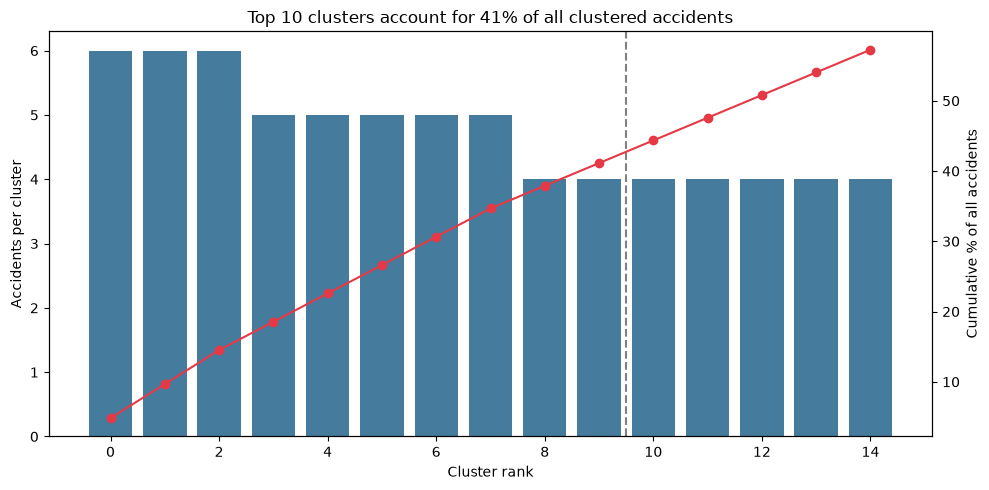

In [10]:
show = blackspots.head(15)
share = blackspots.head(10)["accident_count"].sum() / blackspots["accident_count"].sum()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(show.index, show["accident_count"], color="#457b9d")
ax1.axvline(9.5, color="grey", ls="--")
ax1.set_xlabel("Cluster rank")
ax1.set_ylabel("Accidents per cluster")

ax2 = ax1.twinx()
ax2.plot(show.index, show["accident_count"].cumsum()
         / blackspots["accident_count"].sum() * 100,
         color="#e63946", marker="o")
ax2.set_ylabel("Cumulative % of all accidents")
ax1.set_title(f"Top 10 clusters account for {share:.0%} of all clustered accidents")
plt.tight_layout()
plt.show()

#### Key Findings
---

- All **top 10 black spots** were located at or immediately next to **road intersections**.
- **No fatalities** were recorded at any of the top 10 black spots, although several locations recorded multiple injuries.
- Most black spots were concentrated in the **southern urban areas** of Okinawa, particularly around **Naha, Ginowan, Tomigusuku, and Chatan**.
- The findings were cross-checked against official **National Police Agency (NPA)** road safety reports. **Isa Intersection (Ginowan)** and **Nakachi East Intersection (Tomigusuku)** were independently identified as major accident locations in 2024.
- Black spots were identified by clustering accidents using rounded coordinates (approximately **110 m**). Large intersections may therefore be split into two nearby clusters, which, I believe is what we observed at around the Tomigusuku junction.

---

#### Top 10 Black Spots

| Rank | Location | Accidents | Injured | Fatalities |
|---:|---|---:|---:|---:|
| 1 | Route 58 / Route 81, Isa (Ginowan) | 6 | 8 | 0 |
| 2 | Kumoji, Naha City | 6 | 8 | 0 |
| 3 | Route 58 / Shisa Street | 6 | 9 | 0 |
| 4 | Route 82 / Route 29 (Naha–Itoman Line) | 5 | 8 | 0 |
| 5 | Tomigusuku Nakachi IC | 5 | 7 | 0 |
| 6 | Route 58 / Route 130 | 5 | 6 | 0 |
| 7 | Route 48 / Route 507 | 5 | 6 | 0 |
| 8 | Route 329 / Route 26 / Kariyushi Dori | 5 | 5 | 0 |
| 9 | Chatan Town (off Route 58) | 4 | 4 | 0 |
| 10 | Route 82 / Route 329, Naha City | 4 | 5 | 0 |


#### 🔎 Observation

**Tomigusuku Nakachi IC** may be the largest accident hotspot in the dataset. Because the intersection straddles the boundary of the ~110 m grid cells used for clustering, its accidents were split into **two adjacent coordinate clusters** (26.176, 127.668 and 26.176, 127.669) rather than merged into one. When considered together, these two adjacent cells likely represent the highest concentration of accidents in the dataset.


#### Possible Contributing Factors

The data does not identify the causes of these accidents. However, possible contributing factors include:

- High traffic volume
- Multiple turning and merging movements
- Complex intersection layouts
- Traffic signal timing

Further investigation is recommended to determine whether improvements such as signal timing changes, road design changes, or targeted enforcement could reduce accidents at these locations.